# MRI Super-Resolution — Image Quality Assessment

This notebook evaluates reconstruction quality of MRI super-resolution outputs on the **IXI dataset** using eight IQA metrics implemented in `main.py`.

---

## Metric Reference Thresholds

Thresholds derived from medical-imaging literature (MRI SR and image translation benchmarks).  
See `metrik_evaluation/report.md` for detailed justification and source papers.

| Metric | Direction | Perfect | Excellent | Good | Average | Bad |
|---|---|---|---|---|---|---|
| PSNR (dB) | ↑ higher | ∞ | > 40 | 33 – 40 | 25 – 33 | < 25 |
| SSIM | ↑ higher | 1.0 | > 0.97 | 0.90 – 0.97 | 0.75 – 0.90 | < 0.75 |
| LPIPS | ↓ lower | 0 | < 0.05 | 0.05 – 0.10 | 0.10 – 0.20 | > 0.20 |
| DISTS | ↓ lower | 0 | < 0.05 | 0.05 – 0.12 | 0.12 – 0.25 | > 0.25 |
| RadImageNet-LPIPS | ↓ lower | 0 | < 0.03 | 0.03 – 0.07 | 0.07 – 0.15 | > 0.15 |
| CLIP-IQA | ↑ higher | 1.0 | > 0.7 | 0.5 – 0.7 | 0.3 – 0.5 | < 0.3 |
| BRISQUE † | ↓ lower | 0 | < 10 | 10 – 30 | 30 – 60 | > 60 |
| NIQE † | ↓ lower | ~0 | < 2.5 | 2.5 – 4 | 4 – 10 | > 10 |

> **† BRISQUE / NIQE caveat:** Both metrics were designed for 8-bit natural images.  
> On MRI data, observed ranges are BRISQUE: 43 – 156 and NIQE: 22 – 93 (Müller et al., 2024).  
> Absolute values are **not reliable** for MRI — use them only for relative, within-study comparisons.

---

## Setup

The notebook lives in `src/`. The cell below ensures the working directory is always the **project root** so that the relative paths in `constants.py` (`data/`, `report/`, `models/`) resolve correctly regardless of how Jupyter or nbconvert was launched.

In [1]:
import os
import sys
from pathlib import Path

# Move to project root if nbconvert/Jupyter set cwd to src/
_cwd = Path.cwd()
if _cwd.name == "src":
    os.chdir(_cwd.parent)

# Make src/ importable
sys.path.insert(0, str(Path("src").resolve()))

print("Working directory:", Path.cwd())

Working directory: /mnt/home/stud-jagl1011/Documents/Projektarbeit_1/framework


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from main import evaluate

## Evaluation

Calls `evaluate()` from `main.py`, which:
1. Loads the input volume and optional ground-truth reference defined in `constants.py`.
2. Iterates over all slices, skipping empty ones.
3. Computes all eight IQA metrics per slice — **no files are written**.
4. Returns an `EvaluationResult`; call `result.generate_report()` in the optional block below to write outputs.

In [3]:
result = evaluate()
df = result.to_frame()

print(f"Total slices : {len(df)}")
print(f"Non-empty    : {(~df['is_empty']).sum()}")
df.head()

[IXI661-HH-2788-T1_smore4.nii.gz] tensor size: (256, 1, 192, 256)


[IXI661-HH-2788-T1.nii.gz] tensor size: (256, 1, 192, 256)


Loading pretrained model LPIPS from /tmp/xdgcache-stud-jagl1011/torch/hub/pyiqa/LPIPS_v0.1_alex-df73285e.pth


Loading pretrained model DISTS from /tmp/xdgcache-stud-jagl1011/torch/hub/pyiqa/DISTS_weights-f5e65c96.pth


Total slices : 256
Non-empty    : 240


,image_id,source_model,mode,slice_index,is_empty,psnr,ssim,lpips,dists,radimagenet_lpips,clipiqa,brisque,niqe
0,IXI661-HH-2788-T1_smore4_s000,None,full_reference,0,False,39.921623,0.972180,0.013563,0.065622,0.399213,0.402959,51.851746,14.589263
1,IXI661-HH-2788-T1_smore4_s001,None,full_reference,1,False,39.920605,0.971641,0.016646,0.056246,0.404057,0.424813,45.644714,9.735456
2,IXI661-HH-2788-T1_smore4_s002,None,full_reference,2,False,40.022511,0.971061,0.013485,0.057847,0.406142,0.398854,48.106628,7.528473
3,IXI661-HH-2788-T1_smore4_s003,None,full_reference,3,False,40.022026,0.970239,0.012717,0.055332,0.414394,0.406865,50.369812,7.136506
4,IXI661-HH-2788-T1_smore4_s004,None,full_reference,4,False,40.038887,0.969817,0.013795,0.053847,0.426875,0.385881,47.709656,7.948730


## Descriptive Statistics

In [4]:
metric_cols = ["psnr", "ssim", "lpips", "dists", "radimagenet_lpips", "clipiqa", "brisque", "niqe"]
active = df[~df["is_empty"]]
active[metric_cols].describe().round(4)

,psnr,ssim,lpips,dists,radimagenet_lpips,clipiqa,brisque,niqe
count,240.0000,240.0000,240.0000,240.0000,240.0000,240.0000,240.0000,240.0000
mean,38.9578,0.9708,0.0153,0.0515,0.3911,0.3769,35.9783,10.1783
std,1.1489,0.0045,0.0077,0.0151,0.2675,0.0766,20.1848,5.7444
min,36.9143,0.9644,0.0013,0.0178,0.0984,0.1545,10.8557,4.4102
25%,38.0512,0.9667,0.0071,0.0351,0.1820,0.3409,23.7921,6.0018
50%,38.6786,0.9695,0.0161,0.0554,0.2429,0.3904,29.8063,8.8498
75%,39.9145,0.9751,0.0209,0.0639,0.6984,0.4302,42.0816,11.7049
max,41.0288,0.9786,0.0339,0.0805,0.9087,0.5046,109.1481,30.1090


## Per-Metric Score Distributions

Each histogram shows the distribution of values across all non-empty slices.  
The coloured vertical lines mark the **Good / Average** thresholds from the reference table above.

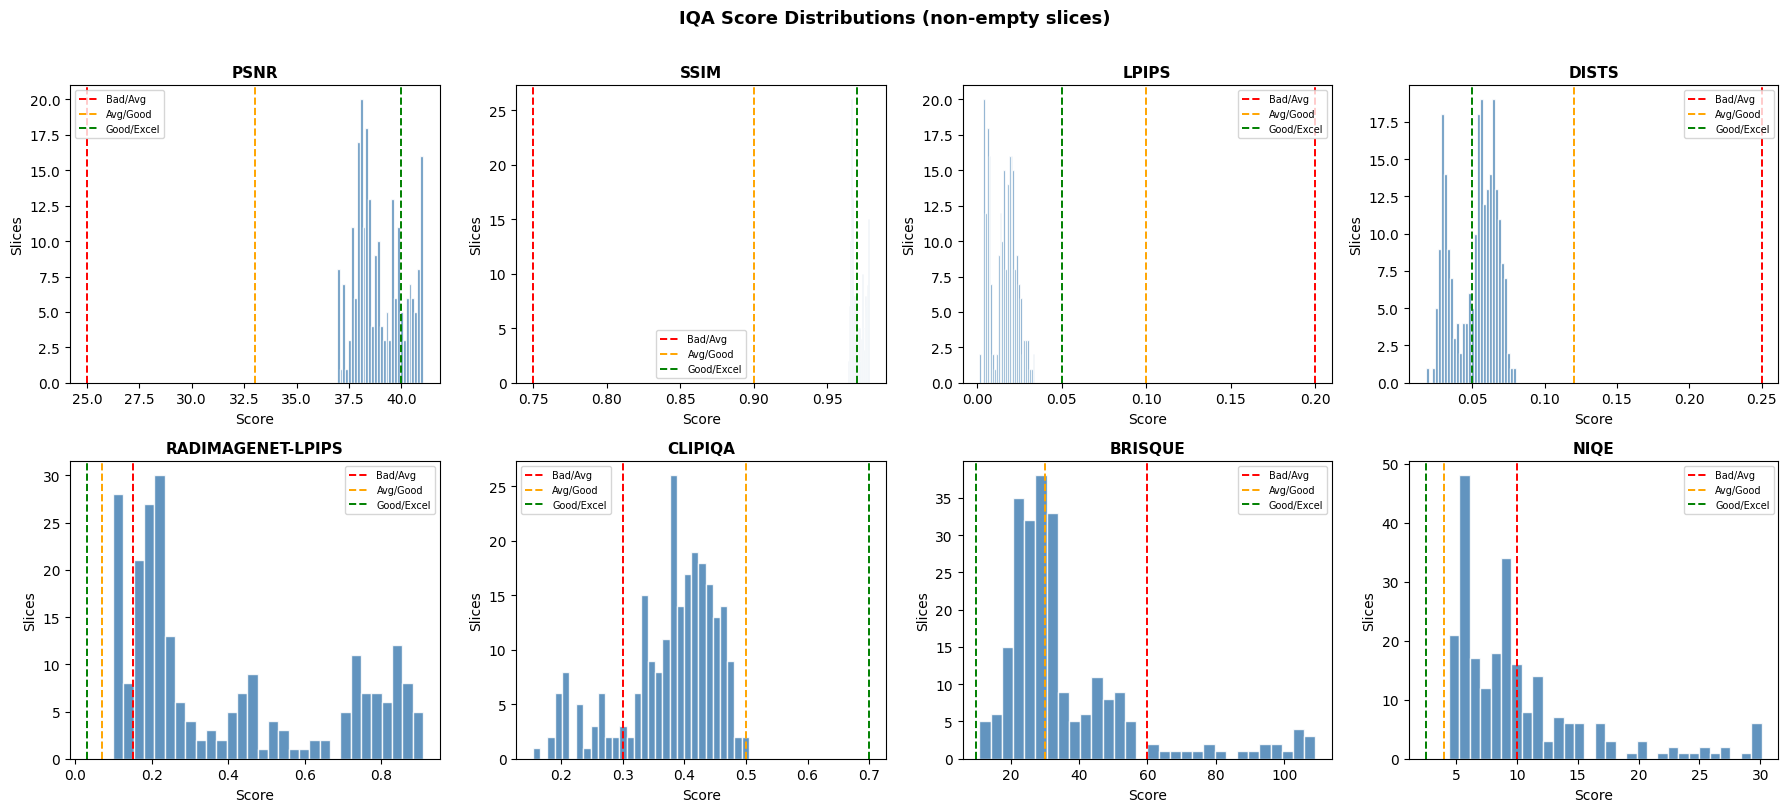

In [5]:
# Threshold lines: (value, label, colour)
THRESHOLDS = {
    "psnr":              [(25, "Bad/Avg", "red"), (33, "Avg/Good", "orange"), (40, "Good/Excel", "green")],
    "ssim":              [(0.75, "Bad/Avg", "red"), (0.90, "Avg/Good", "orange"), (0.97, "Good/Excel", "green")],
    "lpips":             [(0.20, "Bad/Avg", "red"), (0.10, "Avg/Good", "orange"), (0.05, "Good/Excel", "green")],
    "dists":             [(0.25, "Bad/Avg", "red"), (0.12, "Avg/Good", "orange"), (0.05, "Good/Excel", "green")],
    "radimagenet_lpips": [(0.15, "Bad/Avg", "red"), (0.07, "Avg/Good", "orange"), (0.03, "Good/Excel", "green")],
    "clipiqa":           [(0.30, "Bad/Avg", "red"), (0.50, "Avg/Good", "orange"), (0.70, "Good/Excel", "green")],
    "brisque":           [(60, "Bad/Avg", "red"), (30, "Avg/Good", "orange"), (10, "Good/Excel", "green")],
    "niqe":              [(10, "Bad/Avg", "red"), (4, "Avg/Good", "orange"), (2.5, "Good/Excel", "green")],
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, metric_cols):
    data = active[col].dropna()
    ax.hist(data, bins=30, color="steelblue", edgecolor="white", alpha=0.85)
    for val, label, color in THRESHOLDS.get(col, []):
        ax.axvline(val, color=color, linestyle="--", linewidth=1.4, label=label)
    ax.set_title(col.upper().replace("_", "-"), fontsize=11, fontweight="bold")
    ax.set_xlabel("Score")
    ax.set_ylabel("Slices")
    ax.legend(fontsize=7)

fig.suptitle("IQA Score Distributions (non-empty slices)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Quality Band Classification

Each slice is classified into **Bad / Average / Good / Excellent** for every metric based on the reference thresholds.

In [6]:
def classify_psnr(v):      return "Excellent" if v > 40   else ("Good" if v > 33   else ("Average" if v > 25   else "Bad"))
def classify_ssim(v):      return "Excellent" if v > 0.97 else ("Good" if v > 0.90 else ("Average" if v > 0.75 else "Bad"))
def classify_lpips(v):     return "Excellent" if v < 0.05 else ("Good" if v < 0.10 else ("Average" if v < 0.20 else "Bad"))
def classify_dists(v):     return "Excellent" if v < 0.05 else ("Good" if v < 0.12 else ("Average" if v < 0.25 else "Bad"))
def classify_rad_lpips(v): return "Excellent" if v < 0.03 else ("Good" if v < 0.07 else ("Average" if v < 0.15 else "Bad"))
def classify_clipiqa(v):   return "Excellent" if v > 0.70 else ("Good" if v > 0.50 else ("Average" if v > 0.30 else "Bad"))
def classify_brisque(v):   return "Excellent" if v < 10   else ("Good" if v < 30   else ("Average" if v < 60   else "Bad"))
def classify_niqe(v):      return "Excellent" if v < 2.5  else ("Good" if v < 4.0  else ("Average" if v < 10.0 else "Bad"))

classifiers = {
    "psnr": classify_psnr, "ssim": classify_ssim,
    "lpips": classify_lpips, "dists": classify_dists,
    "radimagenet_lpips": classify_rad_lpips, "clipiqa": classify_clipiqa,
    "brisque": classify_brisque, "niqe": classify_niqe,
}

band_frames = {}
for col, fn in classifiers.items():
    s = active[col].dropna()
    band_frames[col] = s.apply(fn).value_counts()

band_df = pd.DataFrame(band_frames).T.fillna(0).astype(int)
for b in ["Excellent", "Good", "Average", "Bad"]:
    if b not in band_df.columns:
        band_df[b] = 0
band_df = band_df[["Excellent", "Good", "Average", "Bad"]]
band_df

,Excellent,Good,Average,Bad
psnr,54,186,0,0
ssim,113,127,0,0
lpips,240,0,0,0
dists,90,150,0,0
radimagenet_lpips,0,0,35,205
clipiqa,0,1,202,37
brisque,0,122,95,23
niqe,0,0,161,79


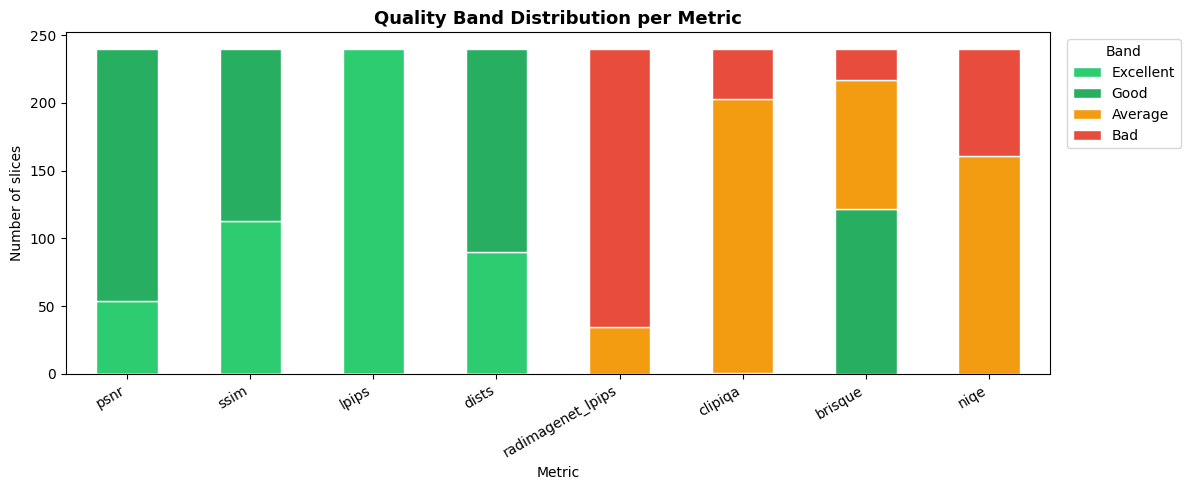

In [7]:
colors = ["#2ecc71", "#27ae60", "#f39c12", "#e74c3c"]
ax = band_df.plot(kind="bar", stacked=True, figsize=(12, 5), color=colors, edgecolor="white")
ax.set_title("Quality Band Distribution per Metric", fontsize=13, fontweight="bold")
ax.set_xlabel("Metric")
ax.set_ylabel("Number of slices")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(title="Band", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Mean Score per Metric with Band Context

In [8]:
means = active[metric_cols].mean().round(4)
stds  = active[metric_cols].std().round(4)

summary = pd.DataFrame({"mean": means, "std": stds})
summary["band"] = [classifiers[col](means[col]) for col in metric_cols]
summary

,mean,std,band
psnr,38.9578,1.1489,Good
ssim,0.9708,0.0045,Excellent
lpips,0.0153,0.0077,Excellent
dists,0.0515,0.0151,Good
radimagenet_lpips,0.3911,0.2675,Bad
clipiqa,0.3769,0.0766,Average
brisque,35.9783,20.1848,Average
niqe,10.1783,5.7444,Bad


## Slice-Level View: Best and Worst Slices

Identifies the slice index with the best and worst PSNR value among non-empty slices.

In [9]:
psnr_valid = active[["slice_index", "psnr", "ssim", "lpips", "dists"]].dropna(subset=["psnr"])

best_row  = psnr_valid.loc[psnr_valid["psnr"].idxmax()]
worst_row = psnr_valid.loc[psnr_valid["psnr"].idxmin()]

print("Best slice (highest PSNR):")
print(best_row.to_string(), "\n")
print("Worst slice (lowest PSNR):")
print(worst_row.to_string())

Best slice (highest PSNR):
slice_index    210.000000
psnr            41.028831
ssim             0.973018
lpips            0.004386
dists            0.025999 

Worst slice (lowest PSNR):
slice_index    80.000000
psnr           36.914322
ssim            0.964881
lpips           0.023344
dists           0.063313


---

## Optional: Generate Full Report

The cell below writes the **CSV report** and **segmentation mask images** (slice / mask / overlay PNG for the best slice of each metric) to disk.

**Edit `report_path`** to change the output location, then run the cell.

In [10]:
from pathlib import Path

report_path = Path("report") / "IXI661_report.csv"   # <- edit output path here

result.generate_report(report_path)

CSV written: report/IXI661_report.csv


[IXI661-HH-2788-T1_smore4.nii.gz] psnr best slice=210 -> IXI661-HH-2788-T1_smore4_psnr_s210_slice.png, IXI661-HH-2788-T1_smore4_psnr_s210_mask.png, IXI661-HH-2788-T1_smore4_psnr_s210_overlay.png
[IXI661-HH-2788-T1_smore4.nii.gz] ssim best slice=162 -> IXI661-HH-2788-T1_smore4_ssim_s162_slice.png, IXI661-HH-2788-T1_smore4_ssim_s162_mask.png, IXI661-HH-2788-T1_smore4_ssim_s162_overlay.png
[IXI661-HH-2788-T1_smore4.nii.gz] lpips best slice=239 -> IXI661-HH-2788-T1_smore4_lpips_s239_slice.png, IXI661-HH-2788-T1_smore4_lpips_s239_mask.png, IXI661-HH-2788-T1_smore4_lpips_s239_overlay.png
[IXI661-HH-2788-T1_smore4.nii.gz] dists best slice=239 -> IXI661-HH-2788-T1_smore4_dists_s239_slice.png, IXI661-HH-2788-T1_smore4_dists_s239_mask.png, IXI661-HH-2788-T1_smore4_dists_s239_overlay.png
[IXI661-HH-2788-T1_smore4.nii.gz] radimagenet_lpips best slice=117 -> IXI661-HH-2788-T1_smore4_radimagenet_lpips_s117_slice.png, IXI661-HH-2788-T1_smore4_radimagenet_lpips_s117_mask.png, IXI661-HH-2788-T1_smore4_

,image_id,source_model,mode,slice_index,is_empty,psnr,ssim,lpips,dists,radimagenet_lpips,clipiqa,brisque,niqe
0,IXI661-HH-2788-T1_smore4_s000,None,full_reference,0,False,39.921623,0.972180,0.013563,0.065622,0.399213,0.402959,51.851746,14.589263
1,IXI661-HH-2788-T1_smore4_s001,None,full_reference,1,False,39.920605,0.971641,0.016646,0.056246,0.404057,0.424813,45.644714,9.735456
2,IXI661-HH-2788-T1_smore4_s002,None,full_reference,2,False,40.022511,0.971061,0.013485,0.057847,0.406142,0.398854,48.106628,7.528473
3,IXI661-HH-2788-T1_smore4_s003,None,full_reference,3,False,40.022026,0.970239,0.012717,0.055332,0.414394,0.406865,50.369812,7.136506
4,IXI661-HH-2788-T1_smore4_s004,None,full_reference,4,False,40.038887,0.969817,0.013795,0.053847,0.426875,0.385881,47.709656,7.948730
...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,IXI661-HH-2788-T1_smore4_s251,None,full_reference,251,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
252,IXI661-HH-2788-T1_smore4_s252,None,full_reference,252,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
253,IXI661-HH-2788-T1_smore4_s253,None,full_reference,253,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
254,IXI661-HH-2788-T1_smore4_s254,None,full_reference,254,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
